In [74]:

def read_config(path="config.txt"):
    config = {}
    with open(path) as f:
        for line in f:
            if "=" in line:
                key, value = line.split("=")
                key = key.strip()
                val = value.strip()
                # Intenta convertir a número (int o float)
                try:
                    if "." in val or "E" in val or "e" in val:
                        config[key] = float(val)
                    else:
                        config[key] = int(val)
                except ValueError:
                    config[key] = val
    return config

cfg = read_config()
print(cfg)


{'N': 108, 'L': 6.463304, 'sigma': 1.0, 'eps': 1.0, 'm': 1.0, 'dc': 2.5, 'dt': 0.005, 'gamma': 0.5, 'kB': 1.0, 'T_target': 1.5, 'N_minE': 10000, 'N_eq': 50000, 'N_steps': 60000, 'Vc': -0.016317}


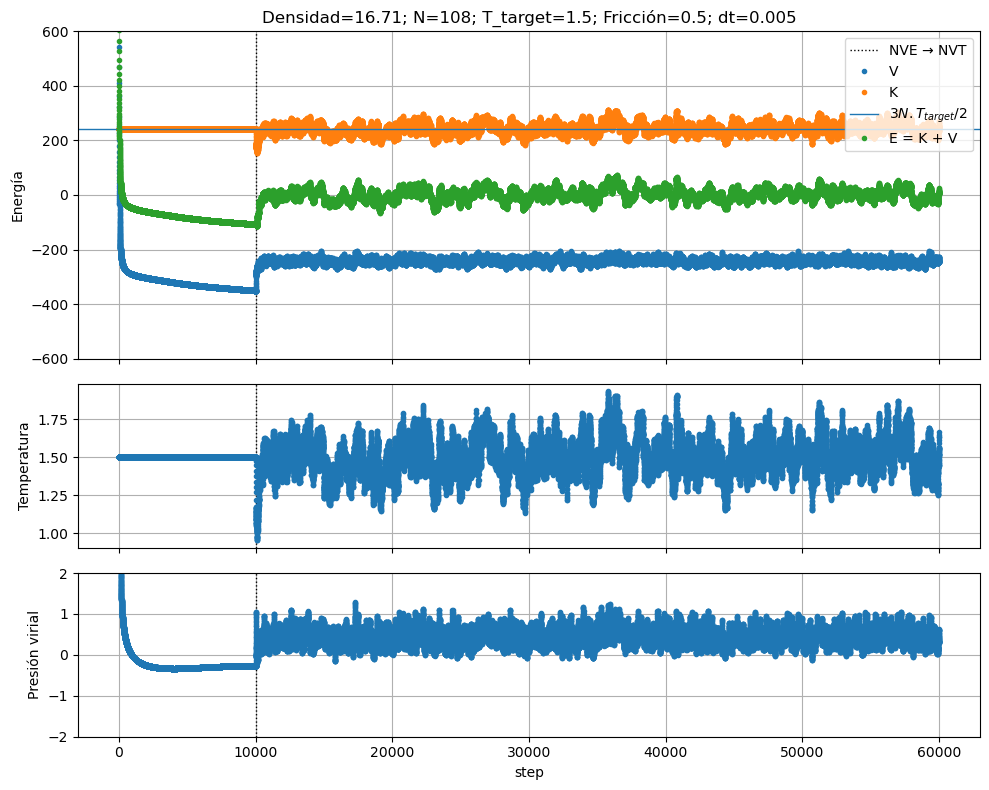

In [91]:
import numpy as np
import matplotlib.pyplot as plt
cfg = read_config()
N = cfg["N"]
L = cfg["L"]
densidad = N/L
T_target = cfg["T_target"]
equil = np.loadtxt("mediciones.dat")
index, K, V, E, T, P = equil.T

fig, axs = plt.subplots(3,1, figsize=(10,8), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})
plt.subplots_adjust(hspace=0.1)
axs[0].set_title(f"Densidad={densidad:.2f}; N={N}; T_target={T_target}; Fricción={cfg["gamma"]}; dt={cfg["dt"]}")
axs[0].axvline(cfg["N_minE"], ls=":", lw=1, c="k", label = "NVE → NVT")
axs[1].axvline(cfg["N_minE"], ls=":", lw=1, c="k")
axs[2].axvline(cfg["N_minE"], ls=":", lw=1, c="k")

axs[0].plot(index, V, ".", label = "V")
axs[0].plot(index, K, ".", label = "K")
axs[0].axhline(3*N*T_target/2, lw=1, label = r"$3N.T_{target}/2$")
axs[0].plot(index, E, ".", label = "E = K + V")
axs[1].plot(index, T, ".")
axs[2].plot(index, P, ".")
axs[0].legend(loc="upper right")
axs[0].set_ylim(-600, 600)
#axs[1].legend()
axs[2].set_xlabel("step")
axs[0].set_ylabel("Energía")
axs[1].set_ylabel("Temperatura")
axs[2].set_ylabel("Presión virial")
axs[2].set_ylim(-2, 2)
for ax in axs[:-1]:
    ax.label_outer()
axs[0].grid()
axs[1].grid()
axs[2].grid()
plt.tight_layout()
plt.savefig(f"sim_N{N}T{T_target}_g{cfg["gamma"]}_dt{cfg["dt"]}.png")

In [94]:
lin = np.linspace(0.7, 1.4, 10)
lin[1:]- lin[:-1]

array([0.07777778, 0.07777778, 0.07777778, 0.07777778, 0.07777778,
       0.07777778, 0.07777778, 0.07777778, 0.07777778])

Text(0, 0.5, 'Temperatura')

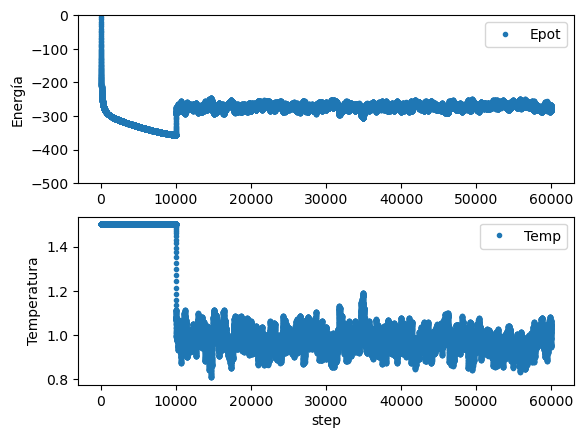

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


equil = np.loadtxt("equilibrio.dat")
index, Epot, T  = equil.T

fig, axs = plt.subplots(2,1)

axs[0].plot(index, Epot, ".", label = "Epot")
axs[1].plot(index, T, ".", label = "Temp")
axs[0].legend()
axs[0].set_ylim(-500, 0)

axs[1].legend()
axs[1].set_xlabel("step")
axs[0].set_ylabel("Energía")
axs[1].set_ylabel("Temperatura")

In [7]:
P

array([ 1.118562e+06,  1.149670e+07,  3.581279e+03, ..., -5.273416e+01,
       -5.071894e+01, -4.868180e+01])

Text(0, 0.5, 'Temperatura')

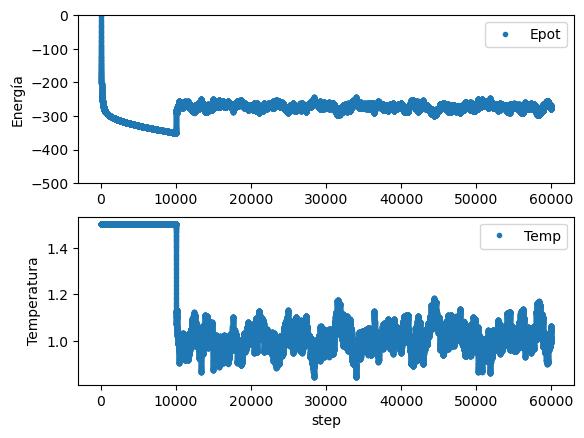

In [2]:
import numpy as np
import matplotlib.pyplot as plt


equil = np.loadtxt("equilibrio.dat")
index, Epot, T  = equil.T

fig, axs = plt.subplots(2,1)

axs[0].plot(index, Epot, ".", label = "Epot")
axs[1].plot(index, T, ".", label = "Temp")
axs[0].legend()
axs[0].set_ylim(-500, 0)
axs[1].legend()
axs[1].set_xlabel("step")
axs[0].set_ylabel("Energía")
axs[1].set_ylabel("Temperatura")

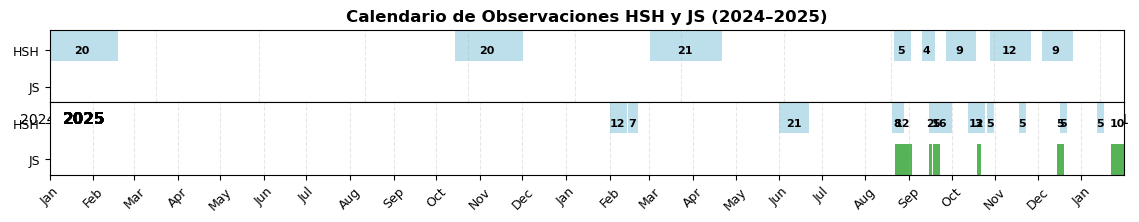

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# --- Función auxiliar ---
def dias(inicio, fin):
    """Cantidad de días entre dos fechas (inclusive)."""
    return (datetime.fromisoformat(fin) - datetime.fromisoformat(inicio)).days + 1

def año_para_fecha(fecha):
    """Asigna año a eje: 2024 o 2025 (2026 se agrupa con 2025)."""
    y = datetime.fromisoformat(fecha).year
    return "2024" if y == 2024 else "2025"

programas = {
    "HSH-2024A-03": [
        ("2024-03-01", "2024-03-20"),
        ("2024-06-27", "2024-07-16")
    ],
    "HSH-2024B-05": [
        ("2024-08-23", "2024-09-12"),
        ("2024-11-02", "2024-11-06"),
        ("2024-11-10", "2024-11-13"),
        ("2024-11-17", "2024-11-25"),
        ("2024-11-30", "2024-12-11"),
        ("2024-12-15", "2024-12-23")
    ],
    "HSH-2025A-05": [
        ("2025-02-01", "2025-02-12"),
        ("2025-02-14", "2025-02-20"),
        ("2025-06-01", "2025-06-21")
    ],
    "HSH-2025B-03": [
        ("2025-08-20", "2025-08-27"),
        ("2025-09-15", "2025-09-30"),
        ("2025-10-13", "2025-10-24"),
        ("2025-10-26", "2025-10-30"),
        ("2025-11-18", "2025-11-22"),
        ("2025-12-17", "2025-12-21"),
        ("2026-01-12", "2026-01-16")
    ],
    "JS-2025B-13": [
        ("2025-08-22", "2025-09-02"),
        ("2025-09-15", "2025-09-16"),
        ("2025-09-18", "2025-09-22"),
        ("2025-10-19", "2025-10-21"),
        ("2025-12-15", "2025-12-19"),
        ("2026-01-22", "2026-01-31")
    ]
}
y = {"HSH":0.6, "JS": 0.2}
# --- Crear estructura agrupada por año y tipo ---
años = ["2024", "2025"]
HSH, JS = {a: [] for a in años}, {a: [] for a in años}
for prog, rangos in programas.items():
    tipo = "JS" if prog.startswith("JS") else "HSH"
    for inicio, fin in rangos:
        año = año_para_fecha(inicio)
        if tipo == "HSH":
            HSH[año].append((inicio, fin, prog))
        else:
            JS[año].append((inicio, fin, prog))

# --- Crear figura ---
fig, axes = plt.subplots(2, 1, figsize=(12, 2.4), gridspec_kw={'hspace': 0})
colors = {"HSH": "lightblue", "JS": "tab:green"}
total = 0
for prog in programas:
    i = 0 if "2024" in prog else 1
    tipo = "HSH" if "HSH" in prog else "JS"
    for inicio, fin in programas[prog]:
        start, end = datetime.fromisoformat(inicio), datetime.fromisoformat(fin)
        dur = dias(inicio, fin)
        
        axes[i].barh(y[tipo], dur, left=start, height=0.3, color=colors[tipo], alpha=0.8)
        axes[i].text(start + (end - start) / 2, y_HSH, f"{dur}", va='center', ha='center',
                fontsize=8, color='black', weight='bold')
    axes[i].set_ylim(0.05, 0.75)
    axes[i].set_yticks([y_HSH, y_JS])
    axes[i].set_yticklabels(["HSH", "JS"], fontsize=9)
    axes[i].grid(axis='x', linestyle='--', alpha=0.3)
    axes[i].text(0.01, 0.6, año, transform=ax.transAxes,
            fontsize=11, fontweight='bold', ha='left', va='bottom')

    axes[i].set_ylim(0.05, 0.75)
    axes[i].set_yticks([y_HSH, y_JS])
    axes[i].set_yticklabels(["HSH", "JS"], fontsize=9)
    axes[i].grid(axis='x', linestyle='--', alpha=0.3)
    axes[i].text(0.01, 0.6, año, transform=ax.transAxes,
            fontsize=11, fontweight='bold', ha='left', va='bottom')



# --- Eje temporal ---
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[-1].set_xlim(datetime(2024, 1, 1), datetime(2026, 1, 31))
plt.xticks(rotation=45, fontsize=9)

# --- Ajuste final ---
axes[0].set_title("Calendario de Observaciones HSH y JS (2024–2025)", fontsize=12, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


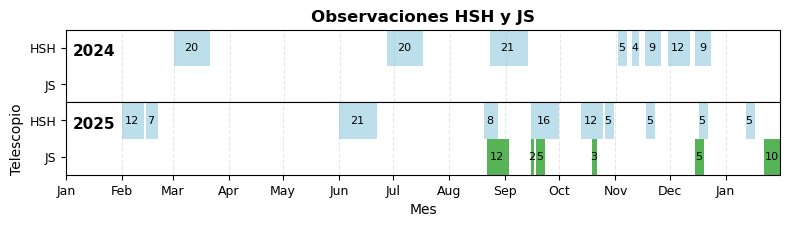

In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# --- Funciones auxiliares ---
def dias(inicio, fin):
    """Cantidad de días entre dos fechas (inclusive)."""
    return (datetime.fromisoformat(fin) - datetime.fromisoformat(inicio)).days + 1

def año_para_fecha(fecha):
    """Asigna el eje según el año."""
    y = datetime.fromisoformat(fecha).year
    if y == 2024:
        return "2024"
    elif y in (2025, 2026):
        return "2025"
    else:
        return None

# --- Datos de entrada ---
programas = {
    "HSH-2024A-03": [
        ("2024-03-01", "2024-03-20"),
        ("2024-06-27", "2024-07-16")
    ],
    "HSH-2024B-05": [
        ("2024-08-23", "2024-09-12"),
        ("2024-11-02", "2024-11-06"),
        ("2024-11-10", "2024-11-13"),
        ("2024-11-17", "2024-11-25"),
        ("2024-11-30", "2024-12-11"),
        ("2024-12-15", "2024-12-23")
    ],
    "HSH-2025A-05": [
        ("2025-02-01", "2025-02-12"),
        ("2025-02-14", "2025-02-20"),
        ("2025-06-01", "2025-06-21")
    ],
    "HSH-2025B-03": [
        ("2025-08-20", "2025-08-27"),
        ("2025-09-15", "2025-09-30"),
        ("2025-10-13", "2025-10-24"),
        ("2025-10-26", "2025-10-30"),
        ("2025-11-18", "2025-11-22"),
        ("2025-12-17", "2025-12-21"),
        ("2026-01-12", "2026-01-16")
    ],
    "JS-2025B-13": [
        ("2025-08-22", "2025-09-02"),
        ("2025-09-15", "2025-09-16"),
        ("2025-09-18", "2025-09-22"),
        ("2025-10-19", "2025-10-21"),
        ("2025-12-15", "2025-12-19"),
        ("2026-01-22", "2026-01-31")
    ]
}

# --- Posiciones verticales por tipo ---
y_pos = {"HSH": 0.75, "JS": 0.25}
colors = {"HSH": "lightblue", "JS": "tab:green"}

# --- Preparar figura ---
fig, axes = plt.subplots(2, 1, figsize=(8, 2.5), sharex=False, gridspec_kw={'hspace': 0})
años = ["2024", "2025"]
total = 0
for i, año in enumerate(años):
    ax = axes[i]
    
    # Dibujar bloques de observación
    for prog, rangos in programas.items():
        tipo = "JS" if prog.startswith("JS") else "HSH"
        for inicio, fin in rangos:
            if año_para_fecha(inicio) != año:
                continue 

            start = datetime.fromisoformat(inicio)
            end = datetime.fromisoformat(fin)
            dur = dias(inicio, fin)
            total+=dur
            ax.barh(y_pos[tipo], dur, left=start, height=0.5,
                    color=colors[tipo], alpha=0.8)
            
            ax.text(start + (end - start)/2, y_pos[tipo],
                    f"{dur}", va='center', ha='center', fontsize=8, color='black')
            
    # --- Estilo del subplot ---
    ax.set_ylim(0, 1)
    ax.set_yticks(list(y_pos.values()))
    ax.set_yticklabels(list(y_pos.keys()), fontsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.text(0.01, 0.6, año, transform=ax.transAxes,
            fontsize=11, fontweight='bold', ha='left', va='bottom')

# --- Ejes temporales ---

axes[0].set_xlim(datetime(2024, 1, 1), datetime(2025, 1, 31))
axes[1].set_xlim(datetime(2025, 1, 1), datetime(2026, 1, 31))

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    for label in ax.get_xticklabels():
        #label.set_rotation(45)
        label.set_fontsize(9)

# --- Título general ---
axes[0].set_title("Observaciones HSH y JS", fontsize=12, weight='bold')
axes[0].set_xticklabels([])
plt.ylabel("Telescopio")
plt.xlabel("Mes")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("obs_casleo.pdf")
#plt.show()


In [49]:
total

233

In [9]:
JS

{'2024': [],
 '2025': [('2025-08-22', '2025-09-02', 'JS-2025B-13'),
  ('2025-09-15', '2025-09-16', 'JS-2025B-13'),
  ('2025-09-18', '2025-09-22', 'JS-2025B-13'),
  ('2025-10-19', '2025-10-21', 'JS-2025B-13'),
  ('2025-12-15', '2025-12-19', 'JS-2025B-13'),
  ('2026-01-22', '2026-01-31', 'JS-2025B-13')]}